In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as pn
import sklearn
from sklearn.model_selection import train_test_split

In [12]:
training = pd.read_csv("dati/dati_spam/spambase_trn.csv")
validation = pd.read_csv("dati/dati_spam/spambase_tst.csv")

In [13]:
X, y = training.iloc[:, :-1], training.iloc[:, -1] 

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### Define the model 

In [16]:
from sklearn.linear_model import LogisticRegression

In [37]:
logisticRegression= LogisticRegression(solver='newton-cg')

### Train the model

In [38]:
logisticRegression.fit(X_train, y_train)

LogisticRegression(solver='newton-cg')

In [39]:
pred = logisticRegression.predict(X_test)

### Check the performance of the model without regularization

In [40]:
from sklearn import metrics

In [54]:
acc = metrics.accuracy_score(y_test, pred)

In [55]:
acc

0.9363354037267081

In [56]:
cm = metrics.confusion_matrix(y_test, pred)

<AxesSubplot:>

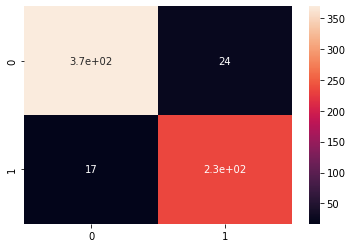

In [57]:
import seaborn as sb
sb.heatmap(cm, annot = True)

#### Train the regularized model 

In [67]:
regularized_lr = LogisticRegression(penalty='l1',solver="saga", max_iter=200)
regularized_lr.fit(X_train,y_train)
reg_pred=regularized_lr.predict(X_test)

/Users/alket/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "


In [68]:
acc = metrics.accuracy_score(y_test, reg_pred)

In [69]:
acc

0.4642857142857143

In [70]:
cm = metrics.confusion_matrix(y_test, reg_pred)

<AxesSubplot:>

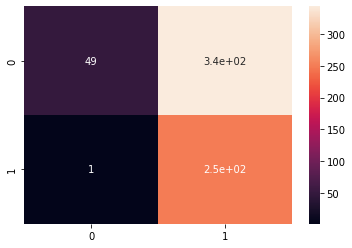

In [71]:
import seaborn as sb
sb.heatmap(cm, annot = True)